# 04 — Backtest & Strategy Comparison

Réplique les exhibits du paper (Exhibit 3, 4, 8) et compare les variants DMN aux benchmarks classiques.

**Variantes comparées :**
- DMN LSTM (baseline) — réplication du paper
- DMN + CPD — contribution principale du paper
- DMN + CPD long-only, positions ∈ (0, 1)
- DMN + CPD long-only (cost-aware 25 bps)
- **LightGBM** — contribution de ce projet
- MACD, TSMOM (Moskowitz), Long-only EW
- SXXR (cap-weighted) — référence indice

**Métriques :** rendement annualisé, vol, Sharpe, Sortino, MDD, Calmar, hit rate, P/L ratio. Brut et rescalé à 15% vol.

In [1]:
from pathlib import Path
import sys, warnings, yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
# portfolio aggregation, transaction costs and plotting helpers, defined in src/backtest.py
from src.backtest import (load_variant, vol_scaled_strategy_return,
                           add_transaction_costs, to_portfolio_series,
                           rescale_to_target_vol,
                           sharpe_at_cost, plot_equity_curves, plot_drawdowns)
# performance metric calculations, defined in src/metrics.py
from src.metrics  import (compute_display_metrics as compute_metrics,
                           format_metrics, rolling_sharpe, yearly_sharpe)


warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (14, 5), "figure.dpi": 100, "axes.grid": True})


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\justi\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\justi\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\justi\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\justi\anaconda3\Lib\site-pack


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\justi\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\justi\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\justi\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\justi\anaconda3\Lib\site-pack

## Configuration

In [2]:
with open(PROJECT_ROOT / "configs" / "default.yaml") as f:
    cfg = yaml.safe_load(f)

PROCESSED_DIR = PROJECT_ROOT / cfg["data"]["processed_dir"]
MODELS_DIR = PROJECT_ROOT / cfg["data"]["processed_mod"]
TARGET_VOL = cfg["vol_target"]
CPD_LBW = cfg["dmn"]["cpd_lbw"]
CPD_STRIDE = cfg["dmn"].get("cpd_stride", 1)
FOLD_TYPE = cfg.get("fold_type", "expanding")
TRANSACTION_COST = cfg["dmn"]["transaction_cost"]

print("Backtest configuration")
print("Models dir      :", MODELS_DIR)
print("Target vol      :", f"{TARGET_VOL:.0%}")
print("CPD setup       :", f"lbw={CPD_LBW}, stride={CPD_STRIDE}")
print("Fold type       :", FOLD_TYPE)
print("Transaction cost:", f"{TRANSACTION_COST * 1e4:.0f} bps")

Backtest configuration
Models dir      : C:\Users\justi\OneDrive\Documents\ESILV PORJECT\Pergam_MSc_2026\data\processed\models
Target vol      : 15%
CPD setup       : lbw=21, stride=5
Fold type       : expanding
Transaction cost: 25 bps


## Chargement des prédictions DMN

In [3]:
# 4 LSTM variants saved by scripts/03bis_walk_forward.py, identified by filename suffix
VARIANTS = {
    "dmn_baseline": "nocpd",
    "dmn_cpd": f"cpd{CPD_LBW}_s{CPD_STRIDE}",
    "dmn_cpd_longonly": f"cpd{CPD_LBW}_s{CPD_STRIDE}_longonly",
    "dmn_cpd_longonly_tc": f"cpd{CPD_LBW}_s{CPD_STRIDE}_longonly_tc25bps",
}

dmn_predictions = {}
for label, suffix in VARIANTS.items():
    pred = load_variant(MODELS_DIR, FOLD_TYPE, suffix)
    if pred.empty:
        print(label, ": no matching prediction file for", suffix)
        continue

    dmn_predictions[label] = pred
    start = pred["date"].min().date()
    end = pred["date"].max().date()
    print(label, ":", f"{len(pred):,}", "rows,", start, "to", end)

if not dmn_predictions:
    raise FileNotFoundError("No DMN predictions found. Run scripts/03bis_walk_forward.py first.")

dmn_baseline : 481,086 rows, 2011-01-03 to 2025-12-31


dmn_cpd : 481,086 rows, 2011-01-03 to 2025-12-31


dmn_cpd_longonly : 481,086 rows, 2011-01-03 to 2025-12-31


dmn_cpd_longonly_tc : 481,086 rows, 2011-01-03 to 2025-12-31


## Chargement des benchmarks

In [4]:
benchmarks = pd.read_csv(PROCESSED_DIR / "benchmark_stoxx600_ew.csv", parse_dates=["date"])
print("Benchmarks:", f"{len(benchmarks):,}", "rows", benchmarks["benchmark"].unique().tolist())

stocks = pd.read_csv(
    PROCESSED_DIR / "stoxx600_processed.csv",
    parse_dates=["date"],
    usecols=[
        "date", "ticker", "1d_arith_ret", "60d_ewm_vol",
        "252d_arith_ret", "macd_8_24", "macd_16_48", "macd_32_96",
    ],
)

# restrict the stock panel to the out-of-sample window covered by the DMN predictions
oos_start = min(pred["date"].min() for pred in dmn_predictions.values())
oos_end = max(pred["date"].max() for pred in dmn_predictions.values())
mask = stocks["date"].between(oos_start, oos_end)
stocks_oos = stocks.loc[mask].copy()

print("Out-of-sample period:", oos_start.date(), "to", oos_end.date())
print("Trading days        :", f"{stocks_oos['date'].nunique():,}")
print("Tickers             :", f"{stocks_oos['ticker'].nunique():,}")

Benchmarks: 10,528 rows ['SXXR', 'EW']


Out-of-sample period: 2011-01-03 to 2025-12-31
Trading days        : 3,913
Tickers             : 1,124


## Stratégies de référence

- **Long-only** : $X_t = 1$
- **Moskowitz (2012)** : $X_t = \mathrm{sgn}(r_{t-252,t})$
- **MACD** : $X_t = \mathrm{sgn}(\bar{\mathrm{MACD}}_t)$ avec paires $(S,L) \in \{(8,24),(16,48),(32,96)\}$

In [5]:
stocks_oos["pos_long_only"] = 1.0
stocks_oos["pos_moskowitz"] = np.sign(stocks_oos["252d_arith_ret"].fillna(0.0))

macd_signal = stocks_oos[["macd_8_24", "macd_16_48", "macd_32_96"]].mean(axis=1)
stocks_oos["pos_macd"] = np.sign(macd_signal.fillna(0.0))

# next_return per ticker -- the return realised the following day (same convention as LightGBM)
stocks_oos["next_ret"] = (stocks_oos
    .sort_values(["ticker", "date"])
    .groupby("ticker")["1d_arith_ret"]
    .shift(-1)
)

# vol-scaled return: pos x (target_vol / ex_ante_vol) x next-day return (paper eq. 11)
for name in ["long_only", "moskowitz", "macd"]:
    stocks_oos[f"strat_{name}_gross"] = vol_scaled_strategy_return(
        stocks_oos[f"pos_{name}"],
        stocks_oos["next_ret"],
        stocks_oos["60d_ewm_vol"],
    )

classical_cols = [
    "date", "ticker", "60d_ewm_vol",
    "pos_long_only", "pos_moskowitz", "pos_macd",
    "strat_long_only_gross", "strat_moskowitz_gross", "strat_macd_gross",
]
gross_cols = ["strat_long_only_gross", "strat_moskowitz_gross", "strat_macd_gross"]
classical = stocks_oos[classical_cols].dropna(subset=gross_cols).reset_index(drop=True)
print(f"Classical strategies computed on {len(classical):,} (stock, date) pairs")

Classical strategies computed on 2,163,790 (stock, date) pairs


## Chargement des prédictions LightGBM

In [6]:
from src.nb03_dmn_v2 import nb03_paths

# load the LightGBM positions already saved by NB03-V2 and join them with realized returns
v2_path = nb03_paths(PROJECT_ROOT)["positions"]

if v2_path.exists():
    pos_v2 = pd.read_parquet(v2_path)

    panel_slim = stocks_oos[["date", "ticker", "1d_arith_ret", "60d_ewm_vol"]].copy()
    panel_slim["next_return"] = (
        panel_slim.sort_values(["ticker", "date"])
        .groupby("ticker")["1d_arith_ret"]
        .shift(-1)
    )

    pos_v2 = pos_v2.merge(panel_slim, on=["date", "ticker"], how="inner")
    pos_v2["strat_ret_gross"] = pos_v2["position"] * pos_v2["next_return"]
    pos_v2["strat_ret"] = pos_v2["strat_ret_gross"]
    pos_v2 = pos_v2.rename(columns={"60d_ewm_vol": "ex_ante_vol"})

    dmn_predictions["lgbm"] = pos_v2
    print("LightGBM loaded")
    print("Rows         :", f"{len(pos_v2):,}")
    print("Period       :", pos_v2["date"].min().date(), "to", pos_v2["date"].max().date())
    print("Mean position:", f"{pos_v2['position'].mean():.3f}")
    print("Position std :", f"{pos_v2['position'].std():.3f}")
else:
    print("LightGBM positions not found at", v2_path)
    print("Run the NB03 LightGBM training notebook first.")

LightGBM loaded
Rows         : 2,000,956
Period       : 2011-01-03 to 2025-12-30
Mean position: 0.502
Position std : 0.011


## Coûts de transaction (éq. C1)

In [7]:
# transaction costs applied to every strategy (eq. C1: cost x |scaled position change|)
for label, df in dmn_predictions.items():
    if "strat_ret_gross" not in df.columns:
        df = df.copy()
        df["strat_ret_gross"] = df["strat_ret"]
    dmn_predictions[label] = add_transaction_costs(
        df, position_col="position", vol_col="ex_ante_vol",
        gross_col="strat_ret_gross", net_col="strat_ret",
        cost=TRANSACTION_COST, target_vol=TARGET_VOL,
    )

for name in ["long_only", "moskowitz", "macd"]:
    classical = add_transaction_costs(
        classical, position_col=f"pos_{name}", vol_col="60d_ewm_vol",
        gross_col=f"strat_{name}_gross", net_col=f"strat_{name}",
        cost=TRANSACTION_COST, target_vol=TARGET_VOL,
    )

## Agrégation en portefeuille

In [8]:
portfolios = {}

# daily return series for each DMN/LightGBM/classical variant (gross and net of costs)
for label, df in dmn_predictions.items():
    portfolios[f"{label}_gross"] = to_portfolio_series(df, "strat_ret_gross")
    portfolios[f"{label}_net"]   = to_portfolio_series(df, "strat_ret")

for name in ["long_only", "moskowitz", "macd"]:
    portfolios[f"{name}_gross"] = to_portfolio_series(classical, f"strat_{name}_gross")
    portfolios[f"{name}_net"]   = to_portfolio_series(classical, f"strat_{name}")

# index benchmark -- STOXX 600 cap-weighted (daily returns)
sxxr_prices  = (benchmarks.loc[benchmarks["benchmark"] == "SXXR"]
                           .set_index("date")["price"].sort_index())
sxxr_ret = sxxr_prices.pct_change()
portfolios["sxxr"] = sxxr_ret.loc[oos_start:oos_end]

print(f"Portfolios computed: {len(portfolios)} series")

Portfolios computed: 17 series


## Métriques de performance

In [9]:
METRIC_COLUMNS = [
    "Returns", "Vol", "Sharpe", "Downside Dev", "Sortino",
    "MDD", "Calmar", "% +ve", "Avg P / Avg L",
]

metric_rows = []
for label, ret_series in portfolios.items():
    metrics = compute_metrics(ret_series)
    metrics["Strategy"] = label
    metric_rows.append(metrics)

metrics_df = pd.DataFrame(metric_rows).set_index("Strategy")
metrics_df = metrics_df[METRIC_COLUMNS]

print()
print("Full-period out-of-sample metrics")
print(f"{TRANSACTION_COST * 1e4:.0f} bps backtest-time costs applied to all variants")
print()
print(format_metrics(metrics_df).to_string())


Full-period out-of-sample metrics
25 bps backtest-time costs applied to all variants

                          Returns      Vol  Sharpe Downside Dev Sortino      MDD  Calmar  % +ve Avg P / Avg L
Strategy                                                                                                     
dmn_baseline_gross         +0.53%   +1.07%  +0.495       +0.90%  +0.590   -3.58%  +0.149  52.1%        +1.017
dmn_baseline_net           -1.13%   +1.08%  -1.048       +0.86%  -1.312  -13.57%  -0.083  43.1%        +1.063
dmn_cpd_gross              +0.18%   +0.80%  +0.219       +0.75%  +0.234   -3.24%  +0.054  51.5%        +0.990
dmn_cpd_net                -1.34%   +0.80%  -1.669       +0.71%  -1.899  -15.59%  -0.086  40.6%        +1.000
dmn_cpd_longonly_gross     +0.86%   +3.09%  +0.279       +2.81%  +0.307   -8.69%  +0.099  54.3%        +0.897
dmn_cpd_longonly_net       +0.16%   +3.09%  +0.051       +2.77%  +0.056   -8.87%  +0.018  51.9%        +0.937
dmn_cpd_longonly_tc_gross  +1.24%

| | **brut (0 bps)** | **net (25 bps)** |
| :--- | :--- | :--- |
| LSTM — sans CPD | +0.495 | −1.048 |
| LSTM + CPD | +0.219 | −1.669 |
| LSTM + CPD long-only | +0.279 | +0.051 |
| LSTM + CPD long-only (cost-aware) | +0.288 | +0.122 |
| **LightGBM long-only** | **+0.382** | **+0.335** |

> Le turnover du LSTM long-short (7.7%) absorbe entièrement le signal à 25 bps. LightGBM long-only (turnover 4.5%) reste positif net de frais.

## Métriques vol-rescalées (Exhibit 4)

In [10]:
rescaled = {}
for label, ret_series in portfolios.items():
    rescaled[label] = rescale_to_target_vol(ret_series, target_vol=TARGET_VOL)

rescaled_rows = []
for label, ret_series in rescaled.items():
    metrics = compute_metrics(ret_series)
    metrics["Strategy"] = label
    rescaled_rows.append(metrics)

rescaled_metrics_df = pd.DataFrame(rescaled_rows).set_index("Strategy")
rescaled_metrics_df = rescaled_metrics_df[METRIC_COLUMNS]

print()
print(f"Vol-rescaled metrics, all at {TARGET_VOL:.0%} vol")
print()
print(format_metrics(rescaled_metrics_df).to_string())


Vol-rescaled metrics, all at 15% vol

                           Returns      Vol  Sharpe Downside Dev Sortino      MDD  Calmar  % +ve Avg P / Avg L
Strategy                                                                                                      
dmn_baseline_gross          +7.42%  +15.00%  +0.495      +12.59%  +0.590  -41.89%  +0.177  52.1%        +1.017
dmn_baseline_net           -15.72%  +15.00%  -1.048      +11.98%  -1.312  -88.35%  -0.178  43.1%        +1.063
dmn_cpd_gross               +3.29%  +15.00%  +0.219      +14.08%  +0.234  -48.67%  +0.068  51.5%        +0.990
dmn_cpd_net                -25.03%  +15.00%  -1.669      +13.18%  -1.899  -96.30%  -0.260  40.6%        +1.000
dmn_cpd_longonly_gross      +4.19%  +15.00%  +0.279      +13.65%  +0.307  -37.10%  +0.113  54.3%        +0.897
dmn_cpd_longonly_net        +0.76%  +15.00%  +0.051      +13.44%  +0.056  -37.86%  +0.020  51.9%        +0.937
dmn_cpd_longonly_tc_gross   +4.31%  +15.00%  +0.288      +12.66%  +0.341 

## Courbes de performance

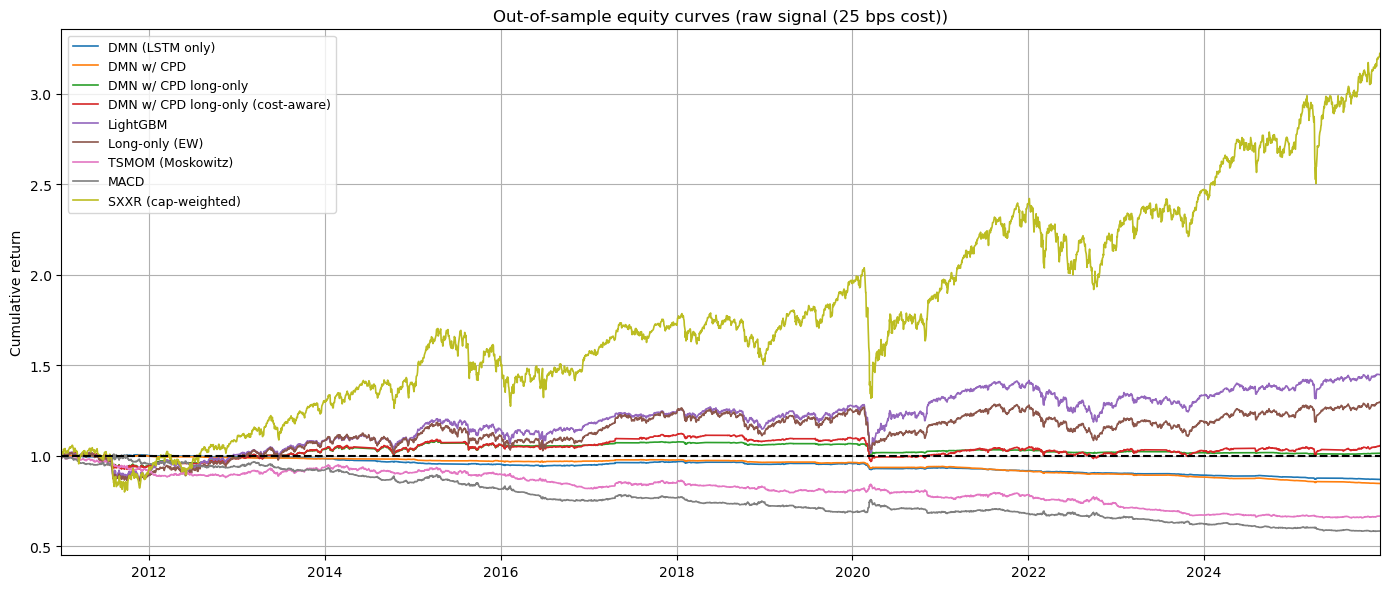

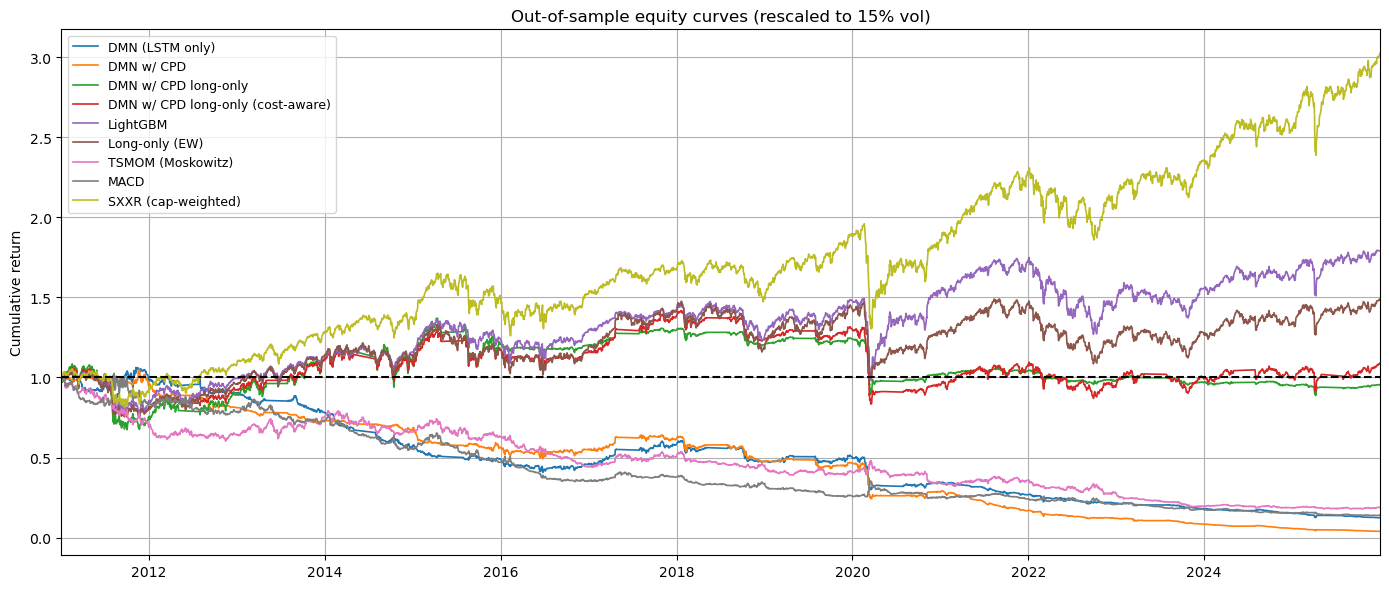

In [11]:
LABELS = {
    "dmn_baseline_net":           "DMN (LSTM only)",
    "dmn_cpd_net":                "DMN w/ CPD",
    "dmn_cpd_longonly_net":       "DMN w/ CPD long-only",
    "dmn_cpd_longonly_tc_net":    "DMN w/ CPD long-only (cost-aware)",
    "lgbm_net":                   "LightGBM",
    "long_only_net":              "Long-only (EW)",
    "moskowitz_net":              "TSMOM (Moskowitz)",
    "macd_net":                   "MACD",
    "sxxr":                       "SXXR (cap-weighted)",
}

# plot_equity_curves imported from src.backtest
plot_equity_curves(portfolios, f"raw signal ({TRANSACTION_COST*1e4:.0f} bps cost)", LABELS).show()
plot_equity_curves(rescaled, f"rescaled to {TARGET_VOL:.0%} vol", LABELS).show()

## Drawdown Analysis

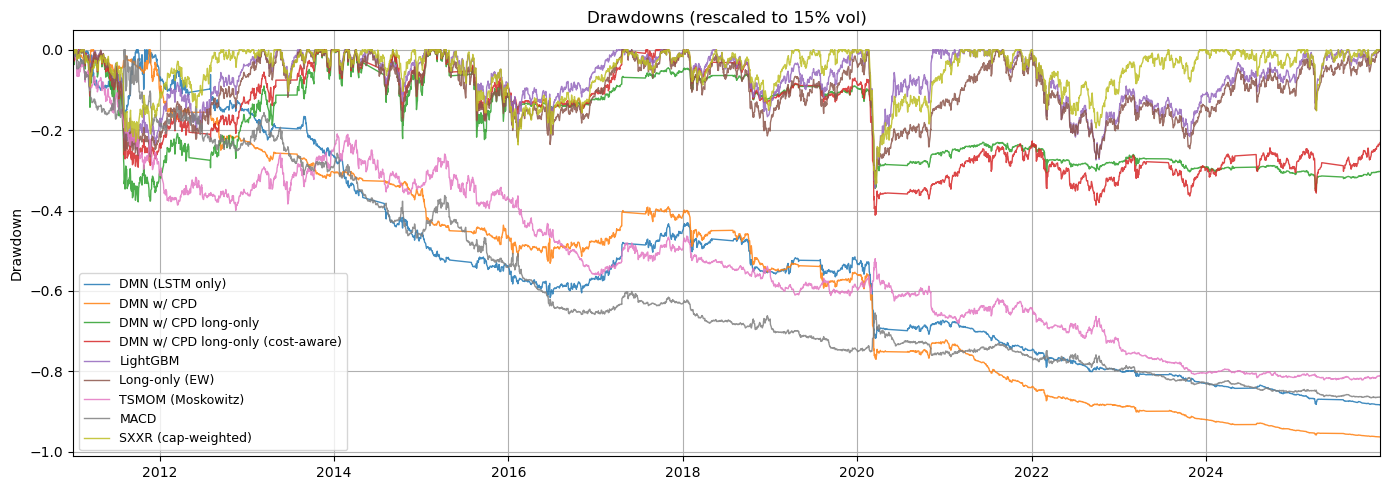

In [12]:
plot_drawdowns(rescaled, TARGET_VOL, LABELS).show()

## Sharpe glissant (252j)

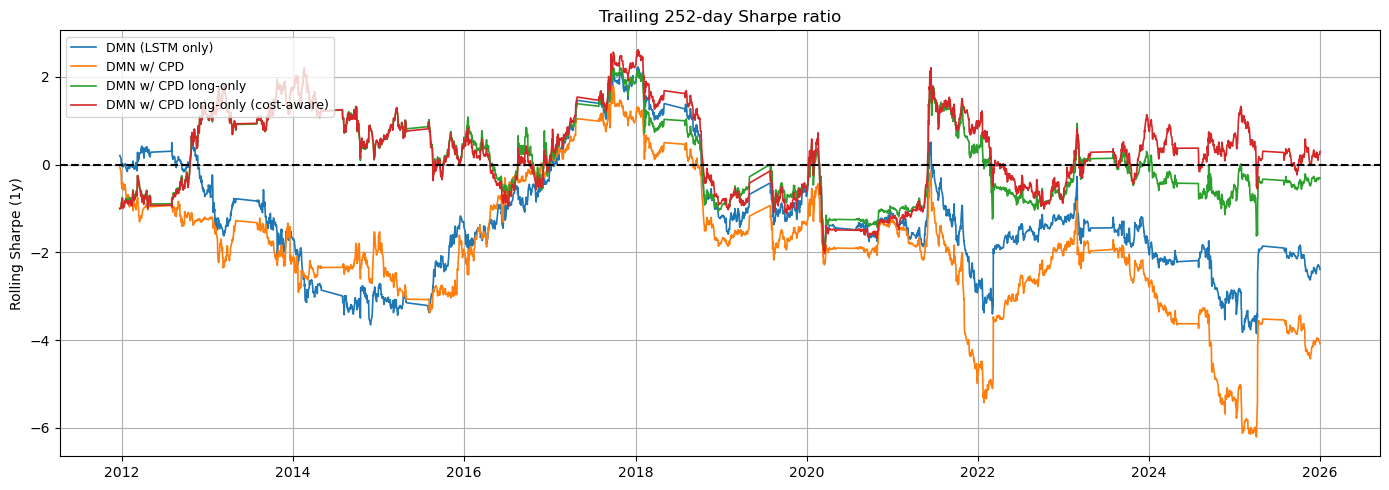

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
for label in ["dmn_baseline_net", "dmn_cpd_net",
               "dmn_cpd_longonly_net", "dmn_cpd_longonly_tc_net"]:
    if label not in portfolios:
        continue
    rs = rolling_sharpe(portfolios[label])
    ax.plot(rs.index, rs.values, lw=1.2, label=LABELS[label])
ax.axhline(0, color="black", lw=1.5, linestyle="--")
ax.set_title("Trailing 252-day Sharpe ratio")
ax.set_ylabel("Rolling Sharpe (1y)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## Sharpe par année

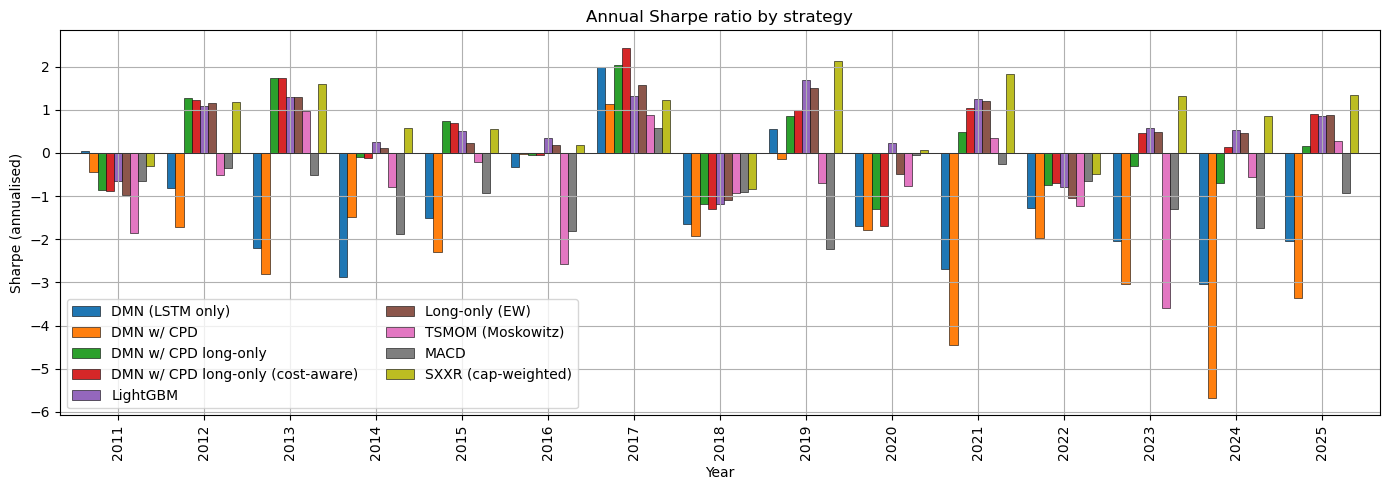


Sharpe by year
      DMN (LSTM only)  DMN w/ CPD  DMN w/ CPD long-only  DMN w/ CPD long-only (cost-aware)  LightGBM  Long-only (EW)  TSMOM (Moskowitz)  MACD  SXXR (cap-weighted)
date                                                                                                                                                              
2011             0.05       -0.43                 -0.86                              -0.89     -0.64           -0.98              -1.85 -0.66                -0.29
2012            -0.80       -1.71                  1.27                               1.23      1.10            1.16              -0.50 -0.34                 1.18
2013            -2.21       -2.79                  1.75                               1.75      1.29            1.30               0.97 -0.51                 1.60
2014            -2.87       -1.50                 -0.10                              -0.12      0.26            0.12              -0.80 -1.89                 0.58
2015  

In [14]:
yearly_table = pd.DataFrame()
for label in LABELS:
    if label in portfolios:
        yearly_table[LABELS[label]] = yearly_sharpe(portfolios[label])

fig, ax = plt.subplots(figsize=(14, 5))
yearly_table.plot(kind="bar", ax=ax, width=0.85, edgecolor="black", linewidth=0.4)
ax.set_title("Annual Sharpe ratio by strategy")
ax.set_xlabel("Year")
ax.set_ylabel("Sharpe (annualised)")
ax.axhline(0, color="black", lw=0.5)
ax.legend(ncol=2, loc="lower left")
plt.tight_layout()
plt.show()

print()
print("Sharpe by year")
print(yearly_table.round(2).to_string())

## Sensibilité aux coûts (Exhibit 8)

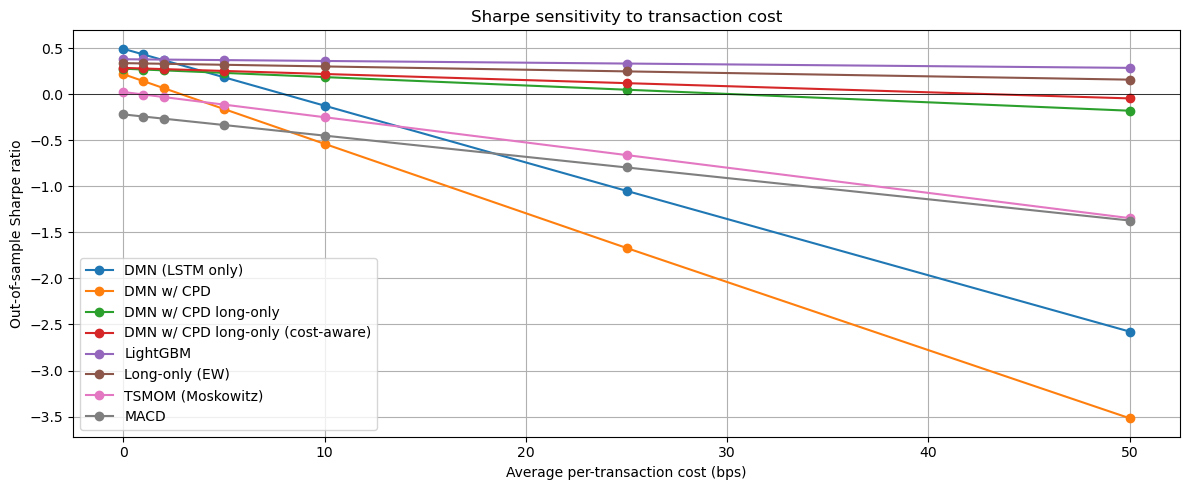


Sharpe at each cost level
            dmn_baseline  dmn_cpd  dmn_cpd_longonly  dmn_cpd_longonly_tc   lgbm  long_only  moskowitz   macd
Cost (bps)                                                                                                  
0                  0.495    0.219             0.279                0.288  0.382      0.339      0.026 -0.218
1                  0.433    0.144             0.270                0.281  0.380      0.336     -0.002 -0.241
2                  0.371    0.068             0.261                0.274  0.378      0.332     -0.029 -0.264
5                  0.186   -0.159             0.233                0.254  0.372      0.321     -0.111 -0.333
10                -0.123   -0.538             0.188                0.221  0.363      0.303     -0.248 -0.448
25                -1.048   -1.669             0.051                0.122  0.335      0.250     -0.659 -0.794
50                -2.577   -3.518            -0.178               -0.044  0.288      0.160     -1.344

In [15]:
# recompute net Sharpe at several assumed cost levels, to see how fast each strategy degrades
COST_GRID_BPS = [0, 1, 2, 5, 10, 25, 50]
COST_GRID = [c * 1e-4 for c in COST_GRID_BPS]

cost_sens = {}
for label, pred in dmn_predictions.items():
    cost_sens[label] = []
    for cost in COST_GRID:
        cost_sens[label].append(sharpe_at_cost(pred, cost))

for name in ["long_only", "moskowitz", "macd"]:
    cost_sens[name] = []
    for cost in COST_GRID:
        sharpe = sharpe_at_cost(
            classical,
            cost,
            position_col=f"pos_{name}",
            vol_col="60d_ewm_vol",
            gross_col=f"strat_{name}_gross",
        )
        cost_sens[name].append(sharpe)

cost_table = pd.DataFrame(cost_sens, index=COST_GRID_BPS)
cost_table.index.name = "Cost (bps)"

fig, ax = plt.subplots(figsize=(12, 5))
for label in cost_table.columns:
    display_label = LABELS.get(label + "_net", LABELS.get(label, label))
    ax.plot(cost_table.index, cost_table[label], marker="o", lw=1.5, label=display_label)

ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("Average per-transaction cost (bps)")
ax.set_ylabel("Out-of-sample Sharpe ratio")
ax.set_title("Sharpe sensitivity to transaction cost")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print()
print("Sharpe at each cost level")
print(cost_table.round(3).to_string())

## Limitations

- **Signal faible** : IC moyen ≈ 0.005, soit ~50.25% de bonnes directions. Légèrement au-dessus du hasard.
- **Ajout CPD = gain marginal sur LightGBM** : le gain reste limité par l'IC, pas par l'architecture.
- **Biais de survivance** : univers STOXX 600 fixé à la composition 2025–2026.
